EVENT_NAME = event_0001
META_PATH   = outdir_population_exactfd/event_0001/meta.json
SIGNAL_PATH = outdir_population_exactfd/event_0001/bns_signal_exact_fd.npz


13:00 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'minimum_frequency': 10.0, 'reference_frequency': 10.0, 'waveform_approximant': 'IMRPhenomXP_NRTidalv3'})
/home/fy6204/.conda/envs/GW/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress thi


=== Frequency grid check ===
exact_freqs.shape     = (4194305,)
self_zero_freq.shape  = (4194305,)
allclose(freq grids)? = True

=== Pure signal comparison: exact signal vs self injection ===
[PURE SIGNAL | CE-A40]
  N(masked)        = 4184065
  ||a||            = 5.610599e-23
  ||b||            = 5.610599e-23
  ||a-b||          = 0.000000e+00
  rel diff / ||a|| = 0.000000e+00
  rel diff / ||b|| = 0.000000e+00
  max |a-b|        = 0.000000e+00
  mean |a-b|       = 0.000000e+00
[PURE SIGNAL | CE-B20]
  N(masked)        = 4184065
  ||a||            = 2.532177e-22
  ||b||            = 2.532177e-22
  ||a-b||          = 0.000000e+00
  rel diff / ||a|| = 0.000000e+00
  rel diff / ||b|| = 0.000000e+00
  max |a-b|        = 0.000000e+00
  mean |a-b|       = 0.000000e+00

=== Noise-only reproducibility check ===
allclose(noise freq grids)? = True
[NOISE ONLY reproducibility | CE-B20]
  N(masked)        = 4184065
  ||a||            = 4.598969e-20
  ||b||            = 4.598969e-20
  ||a-b||      

13:00 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'minimum_frequency': 10.0, 'reference_frequency': 10.0, 'waveform_approximant': 'IMRPhenomXP_NRTidalv3'})
13:00 bilby INFO    : Injected signal in CE-B20:
13:00 bilby INFO    :   optimal SNR = 29.93
13:00 bilby INFO    :   matched filter SNR = 30.38-0.36j
13:00 bilby INFO    :   chi_1 = 0.0
13:00 bilby INFO    :   chi_2 = 0.0
13:00 bilby INFO    :   dec = -0.7052027038698631
13:00 bilby INFO    :   geocent_time = 1126259642.413
13:00 bilby INFO    :   lambda_1 = 949.373696037429
13:00 bilby INFO    :   lambda_2 = 1182.6921558901017
13:00 bilby INFO    :   luminosity_distance = 849.0022901291151
13:00 bilby INFO    :   mass_1 = 1.518223238991255
13:00 bi


=== Total data comparison: (noise + exact signal) vs (noise + self signal) ===
allclose(total freq grids)? = True
[TOTAL DATA | CE-B20]
  N(masked)        = 4184065
  ||a||            = 4.599041e-20
  ||b||            = 4.599041e-20
  ||a-b||          = 0.000000e+00
  rel diff / ||a|| = 0.000000e+00
  rel diff / ||b|| = 0.000000e+00
  max |a-b|        = 0.000000e+00
  mean |a-b|       = 0.000000e+00
[TOTAL DATA | CE-A40]
  N(masked)        = 4184065
  ||a||            = 3.900554e-20
  ||b||            = 3.900554e-20
  ||a-b||          = 0.000000e+00
  rel diff / ||a|| = 0.000000e+00
  rel diff / ||b|| = 0.000000e+00
  max |a-b|        = 0.000000e+00
  mean |a-b|       = 0.000000e+00

=== Plots for CE-A40 ===


/tmp/ipykernel_716034/3338148534.py:210: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[2].set_yscale("log")


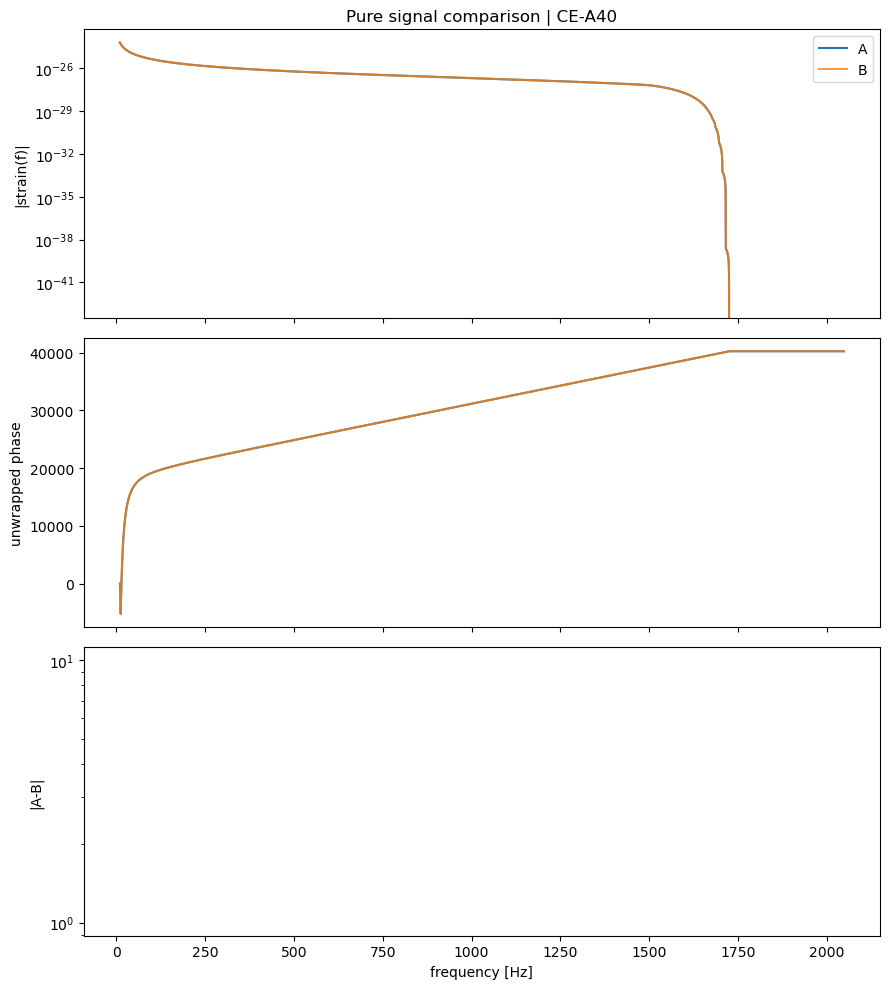

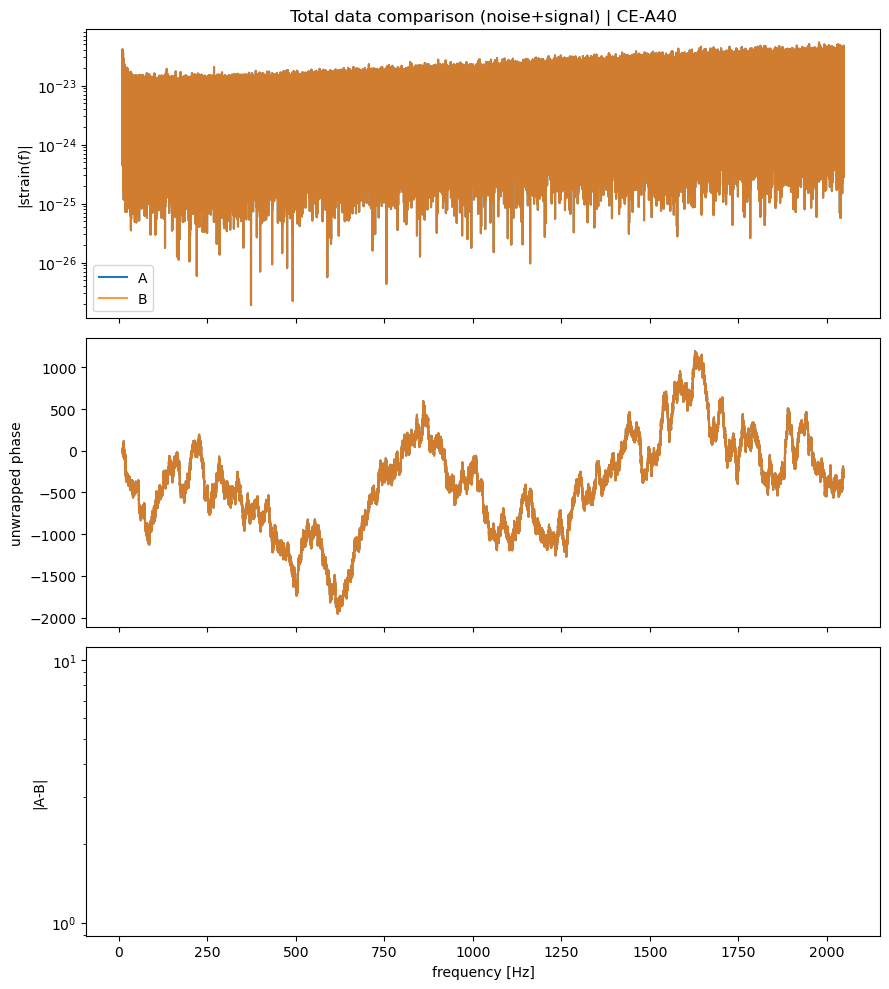

In [1]:
import os
import json
import copy
import numpy as np
import bilby
import matplotlib.pyplot as plt

from bilby.core.utils.random import seed as bilby_seed

# =========================================================
# 0. 你只需要改这里
# =========================================================
POP_OUTDIR = os.environ.get("POP_OUTDIR", "outdir_population_exactfd")
EVENT_INDEX = int(os.environ.get("EVENT_INDEX", "1"))
EVENT_NAME = f"event_{EVENT_INDEX:04d}"

META_PATH = os.path.join(POP_OUTDIR, EVENT_NAME, "meta.json")

# 如果你想强制指定路径，就取消下面注释并改成你的
# META_PATH = "/scratch/.../outdir_population_exactfd/event_0001/meta.json"

# =========================================================
# 1. 读 meta
# =========================================================
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

inj = dict(meta["injection_parameters"])
seg = meta["data_segment"]
noise_seed = int(meta["noise_seed"])

duration = int(seg["duration"])
start_time = float(seg["start_time"])
sampling_frequency = float(seg["sampling_frequency"])
fmin = float(seg["fmin"])

ifo_files = list(meta["reproduction"]["ifo_files"])
waveform_arguments = dict(meta["reproduction"]["waveform_arguments"])
waveform_arguments.pop("frequency_bin_edges", None)
waveform_arguments.pop("fiducial", None)

exact_info = meta.get("exact_signal_file", None)
if exact_info is None:
    raise ValueError("meta.json does not contain exact_signal_file")

signal_path = os.path.join(POP_OUTDIR, EVENT_NAME, exact_info["filename"])
if not os.path.exists(signal_path):
    raise FileNotFoundError(f"Cannot find exact signal file: {signal_path}")

print(f"EVENT_NAME = {EVENT_NAME}")
print(f"META_PATH   = {META_PATH}")
print(f"SIGNAL_PATH = {signal_path}")

# =========================================================
# 2. 读 exact_signal_file
# =========================================================
with np.load(signal_path) as data:
    freq_key = exact_info["frequency_array_key"]
    exact_freqs = np.asarray(data[freq_key])
    exact_detector_signals = {
        ifo_name: np.asarray(data[key])
        for ifo_name, key in exact_info["detector_signal_keys"].items()
    }

# =========================================================
# 3. helper functions
# =========================================================
def make_ifos_zero_noise():
    ifos = bilby.gw.detector.InterferometerList(
        [bilby.gw.detector.load_interferometer(f) for f in ifo_files]
    )
    for ifo in ifos:
        ifo.minimum_frequency = fmin
    ifos.set_strain_data_from_zero_noise(
        sampling_frequency=sampling_frequency,
        duration=duration,
        start_time=start_time,
    )
    for ifo in ifos:
        ifo.minimum_frequency = fmin
    return ifos

def make_ifos_with_noise(seed):
    bilby_seed(seed)
    ifos = bilby.gw.detector.InterferometerList(
        [bilby.gw.detector.load_interferometer(f) for f in ifo_files]
    )
    for ifo in ifos:
        ifo.minimum_frequency = fmin
    ifos.set_strain_data_from_power_spectral_densities(
        sampling_frequency=sampling_frequency,
        duration=duration,
        start_time=start_time,
    )
    for ifo in ifos:
        ifo.minimum_frequency = fmin
    return ifos

def load_exact_signal_dict():
    return copy.deepcopy(exact_detector_signals)

def build_wg_for_self_injection():
    # 这里用“直接根据 injection_parameters 自己 inject”的路径
    # 也就是传统/标准 BNS conversion，而不是 UR conversion
    wg = bilby.gw.WaveformGenerator(
        duration=duration,
        sampling_frequency=sampling_frequency,
        frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star,
        parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
        waveform_arguments=waveform_arguments,
    )
    return wg

def inject_self_signal_zero_noise():
    ifos = make_ifos_zero_noise()
    wg = build_wg_for_self_injection()
    ifos.inject_signal(parameters=inj, waveform_generator=wg)
    out = {}
    for ifo in ifos:
        out[ifo.name] = np.asarray(ifo.strain_data.frequency_domain_strain).copy()
    return np.asarray(ifos[0].frequency_array), out

def inject_self_signal_with_noise(seed):
    ifos = make_ifos_with_noise(seed)
    wg = build_wg_for_self_injection()
    ifos.inject_signal(parameters=inj, waveform_generator=wg)
    out = {}
    for ifo in ifos:
        out[ifo.name] = np.asarray(ifo.strain_data.frequency_domain_strain).copy()
    return np.asarray(ifos[0].frequency_array), out

def build_exact_plus_noise(seed):
    ifos = make_ifos_with_noise(seed)
    out = {}
    for ifo in ifos:
        if ifo.name not in exact_detector_signals:
            raise KeyError(f"{ifo.name} not found in exact detector signals")
        # 先取 noise-only
        strain = np.asarray(ifo.strain_data.frequency_domain_strain).copy()
        # 再加 exact signal
        strain = strain + exact_detector_signals[ifo.name]
        out[ifo.name] = strain
    return np.asarray(ifos[0].frequency_array), out

def build_noise_only(seed):
    ifos = make_ifos_with_noise(seed)
    out = {}
    for ifo in ifos:
        out[ifo.name] = np.asarray(ifo.strain_data.frequency_domain_strain).copy()
    return np.asarray(ifos[0].frequency_array), out

def summarize_difference(label, a, b, freq, fmin=None):
    if a.shape != b.shape:
        print(f"[{label}] shape mismatch: {a.shape} vs {b.shape}")
        return

    mask = np.isfinite(a) & np.isfinite(b)
    if fmin is not None:
        mask &= (freq >= fmin)

    aa = a[mask]
    bb = b[mask]
    diff = aa - bb

    norm_a = np.linalg.norm(aa)
    norm_b = np.linalg.norm(bb)
    norm_diff = np.linalg.norm(diff)

    rel_to_a = norm_diff / norm_a if norm_a > 0 else np.nan
    rel_to_b = norm_diff / norm_b if norm_b > 0 else np.nan
    max_abs = np.max(np.abs(diff)) if diff.size else np.nan
    mean_abs = np.mean(np.abs(diff)) if diff.size else np.nan

    print(f"[{label}]")
    print(f"  N(masked)        = {diff.size}")
    print(f"  ||a||            = {norm_a:.6e}")
    print(f"  ||b||            = {norm_b:.6e}")
    print(f"  ||a-b||          = {norm_diff:.6e}")
    print(f"  rel diff / ||a|| = {rel_to_a:.6e}")
    print(f"  rel diff / ||b|| = {rel_to_b:.6e}")
    print(f"  max |a-b|        = {max_abs:.6e}")
    print(f"  mean |a-b|       = {mean_abs:.6e}")

def plot_comparison(freq, a, b, title, fmin=None, fmax=2048):
    mask = np.isfinite(a) & np.isfinite(b)
    if fmin is not None:
        mask &= (freq >= fmin)
    if fmax is not None:
        mask &= (freq <= fmax)

    ff = freq[mask]
    aa = a[mask]
    bb = b[mask]
    dd = aa - bb

    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

    axes[0].plot(ff, np.abs(aa), label="A")
    axes[0].plot(ff, np.abs(bb), label="B", alpha=0.8)
    axes[0].set_yscale("log")
    axes[0].set_ylabel("|strain(f)|")
    axes[0].set_title(title)
    axes[0].legend()

    axes[1].plot(ff, np.unwrap(np.angle(aa)), label="A")
    axes[1].plot(ff, np.unwrap(np.angle(bb)), label="B", alpha=0.8)
    axes[1].set_ylabel("unwrapped phase")

    axes[2].plot(ff, np.abs(dd))
    axes[2].set_yscale("log")
    axes[2].set_ylabel("|A-B|")
    axes[2].set_xlabel("frequency [Hz]")

    plt.tight_layout()
    plt.show()

# =========================================================
# 4. 先比较频率网格
# =========================================================
self_zero_freq, self_zero_signal = inject_self_signal_zero_noise()

print("\n=== Frequency grid check ===")
print("exact_freqs.shape     =", exact_freqs.shape)
print("self_zero_freq.shape  =", self_zero_freq.shape)
print("allclose(freq grids)? =", np.allclose(exact_freqs, self_zero_freq, rtol=0.0, atol=0.0))

if not np.allclose(exact_freqs, self_zero_freq, rtol=0.0, atol=0.0):
    raise RuntimeError("Frequency grids do not match exactly. Stop here first.")

# =========================================================
# 5. 纯信号比较：exact_signal_file vs self inject
# =========================================================
print("\n=== Pure signal comparison: exact signal vs self injection ===")
for ifo_name in exact_detector_signals.keys():
    summarize_difference(
        f"PURE SIGNAL | {ifo_name}",
        exact_detector_signals[ifo_name],
        self_zero_signal[ifo_name],
        exact_freqs,
        fmin=fmin,
    )

# =========================================================
# 6. noise-only 比较：两次同 seed 生成的 noise 是否一致
# =========================================================
noise_freq_1, noise_only_1 = build_noise_only(noise_seed)
noise_freq_2, noise_only_2 = build_noise_only(noise_seed)

print("\n=== Noise-only reproducibility check ===")
print("allclose(noise freq grids)? =", np.allclose(noise_freq_1, noise_freq_2, rtol=0.0, atol=0.0))
for ifo_name in noise_only_1.keys():
    summarize_difference(
        f"NOISE ONLY reproducibility | {ifo_name}",
        noise_only_1[ifo_name],
        noise_only_2[ifo_name],
        noise_freq_1,
        fmin=fmin,
    )

# =========================================================
# 7. 总数据比较：exact+noise vs selfinject+noise
# =========================================================
exact_noisy_freq, exact_noisy_data = build_exact_plus_noise(noise_seed)
self_noisy_freq, self_noisy_data = inject_self_signal_with_noise(noise_seed)

print("\n=== Total data comparison: (noise + exact signal) vs (noise + self signal) ===")
print("allclose(total freq grids)? =", np.allclose(exact_noisy_freq, self_noisy_freq, rtol=0.0, atol=0.0))

for ifo_name in exact_noisy_data.keys():
    summarize_difference(
        f"TOTAL DATA | {ifo_name}",
        exact_noisy_data[ifo_name],
        self_noisy_data[ifo_name],
        exact_noisy_freq,
        fmin=fmin,
    )

# =========================================================
# 8. 可视化：默认画第一个 IFO
# =========================================================
ifo0 = list(exact_detector_signals.keys())[0]

print(f"\n=== Plots for {ifo0} ===")
plot_comparison(
    exact_freqs,
    exact_detector_signals[ifo0],
    self_zero_signal[ifo0],
    title=f"Pure signal comparison | {ifo0}",
    fmin=fmin,
    fmax=2048,
)

plot_comparison(
    exact_noisy_freq,
    exact_noisy_data[ifo0],
    self_noisy_data[ifo0],
    title=f"Total data comparison (noise+signal) | {ifo0}",
    fmin=fmin,
    fmax=2048,
)

In [2]:
import os
import json
import copy
import numpy as np
import bilby
from astropy.cosmology import FlatLambdaCDM, Planck18

# =========================================================
# 0. 读 meta
# =========================================================
POP_OUTDIR = os.environ.get("POP_OUTDIR", "outdir_population_exactfd")
EVENT_INDEX = int(os.environ.get("EVENT_INDEX", "1"))
EVENT_NAME = f"event_{EVENT_INDEX:04d}"
META_PATH = os.path.join(POP_OUTDIR, EVENT_NAME, "meta.json")

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

inj = dict(meta["injection_parameters"])
m1_det = float(meta["mass_1_detector"])
m2_det = float(meta["mass_2_detector"])

Mc_inj = (m1_det * m2_det) ** (3.0 / 5.0) / (m1_det + m2_det) ** (1.0 / 5.0)
q_inj = min(m1_det, m2_det) / max(m1_det, m2_det)

# =========================================================
# 1. 把你脚本里的 UR 常数照搬过来
# =========================================================
LAMBDA_FIT_NORM = 3500.0
A0_FIT = -0.51480556
A1_FIT = 0.79244108
A2_FIT = -0.30781804
DELTA_TRUE = 0.0
H0_TRUE = float(Planck18.H0.value)

cosmo_fid = FlatLambdaCDM(H0=70.0, Om0=float(Planck18.Om0), Tcmb0=Planck18.Tcmb0)
_z_grid = np.linspace(0.0, 2.0, 20000)
_dL_grid = np.asarray(cosmo_fid.luminosity_distance(_z_grid).value, dtype=float)

def z_from_dL_H0_vec(dL_mpc, H0):
    dL_scaled = np.asarray(dL_mpc, dtype=float) * (np.asarray(H0, dtype=float) / 70.0)
    return np.interp(np.clip(dL_scaled, _dL_grid[0], _dL_grid[-1]), _dL_grid, _z_grid)

def lambda_of_mbar_vec(mbar, delta_a0, delta_a1, delta_a2):
    mbar = np.asarray(mbar, dtype=float)
    poly = (
        1.0
        + A0_FIT * (1.0 + np.asarray(delta_a0, dtype=float))
        + A1_FIT * (1.0 + np.asarray(delta_a1, dtype=float)) * mbar
        + A2_FIT * (1.0 + np.asarray(delta_a2, dtype=float)) * mbar**2
    )
    lam = LAMBDA_FIT_NORM * poly / mbar**5
    lam = np.where(np.isfinite(lam), lam, 0.0)
    return np.maximum(lam, 1e-8)

# =========================================================
# 2. 当前版本：按你脚本原样重现
# =========================================================
def add_ur_current(parameters):
    p = dict(parameters)

    dL = np.asarray(p["luminosity_distance"], dtype=float)
    H0 = np.asarray(p.get("H0_sample", H0_TRUE), dtype=float)
    delta_a0 = np.asarray(p.get("delta_a0", DELTA_TRUE), dtype=float)
    delta_a1 = np.asarray(p.get("delta_a1", DELTA_TRUE), dtype=float)
    delta_a2 = np.asarray(p.get("delta_a2", DELTA_TRUE), dtype=float)

    # 这是你当前脚本最可疑的地方：只有 mass_1 不在时才重算
    if "mass_1" not in p:
        q = np.asarray(p["mass_ratio"], dtype=float)
        Mc = np.asarray(p["chirp_mass"], dtype=float)
        p["mass_1"] = Mc * (1.0 + q) ** (1.0 / 5.0) * q ** (-3.0 / 5.0)
        p["mass_2"] = np.asarray(p["mass_1"], dtype=float) * q

    z = z_from_dL_H0_vec(dL, H0)
    p["redshift_sample"] = z

    m1_src = np.asarray(p["mass_1"], dtype=float) / (1.0 + z)
    m2_src = np.asarray(p["mass_2"], dtype=float) / (1.0 + z)
    p["mass_1_source"] = m1_src
    p["mass_2_source"] = m2_src

    p["lambda_1"] = lambda_of_mbar_vec(m1_src, delta_a0, delta_a1, delta_a2)
    p["lambda_2"] = lambda_of_mbar_vec(m2_src, delta_a0, delta_a1, delta_a2)

    p["lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(
        p["lambda_1"], p["lambda_2"], p["mass_1"], p["mass_2"]
    )
    p["delta_lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(
        p["lambda_1"], p["lambda_2"], p["mass_1"], p["mass_2"]
    )
    return p

def preserve_keys(converted, original, augmented):
    converted = dict(converted)
    for src in (original, augmented):
        for key, value in src.items():
            converted.setdefault(key, value)
    converted.setdefault("phase", original.get("phase", 0.0))
    return converted

def convert_for_waveform_current(parameters):
    original = dict(parameters)
    augmented = add_ur_current(original)
    out = bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters(augmented)
    if isinstance(out, tuple):
        converted, added_keys = out
    else:
        converted, added_keys = out, []
    converted = preserve_keys(converted, original, augmented)
    return converted, added_keys

# =========================================================
# 3. 修正版：每次都重算 mass_1/mass_2，并清掉旧派生键
# =========================================================
DERIVED_KEYS = [
    "mass_1", "mass_2",
    "mass_1_source", "mass_2_source",
    "redshift_sample",
    "lambda_1", "lambda_2",
    "lambda_tilde", "delta_lambda_tilde",
]

def add_ur_fixed(parameters):
    p = dict(parameters)

    # 先清掉旧派生量
    for k in DERIVED_KEYS:
        p.pop(k, None)

    dL = np.asarray(p["luminosity_distance"], dtype=float)
    H0 = np.asarray(p.get("H0_sample", H0_TRUE), dtype=float)
    delta_a0 = np.asarray(p.get("delta_a0", DELTA_TRUE), dtype=float)
    delta_a1 = np.asarray(p.get("delta_a1", DELTA_TRUE), dtype=float)
    delta_a2 = np.asarray(p.get("delta_a2", DELTA_TRUE), dtype=float)

    # 每次都强制重算
    q = np.asarray(p["mass_ratio"], dtype=float)
    Mc = np.asarray(p["chirp_mass"], dtype=float)
    p["mass_1"] = Mc * (1.0 + q) ** (1.0 / 5.0) * q ** (-3.0 / 5.0)
    p["mass_2"] = np.asarray(p["mass_1"], dtype=float) * q

    z = z_from_dL_H0_vec(dL, H0)
    p["redshift_sample"] = z

    m1_src = np.asarray(p["mass_1"], dtype=float) / (1.0 + z)
    m2_src = np.asarray(p["mass_2"], dtype=float) / (1.0 + z)
    p["mass_1_source"] = m1_src
    p["mass_2_source"] = m2_src

    p["lambda_1"] = lambda_of_mbar_vec(m1_src, delta_a0, delta_a1, delta_a2)
    p["lambda_2"] = lambda_of_mbar_vec(m2_src, delta_a0, delta_a1, delta_a2)

    p["lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(
        p["lambda_1"], p["lambda_2"], p["mass_1"], p["mass_2"]
    )
    p["delta_lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(
        p["lambda_1"], p["lambda_2"], p["mass_1"], p["mass_2"]
    )
    return p

def convert_for_waveform_fixed(parameters):
    original = dict(parameters)
    for k in DERIVED_KEYS:
        original.pop(k, None)
    augmented = add_ur_fixed(original)
    out = bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters(augmented)
    if isinstance(out, tuple):
        converted, added_keys = out
    else:
        converted, added_keys = out, []
    converted = preserve_keys(converted, original, augmented)
    return converted, added_keys

# =========================================================
# 4. 构造一个“干净输入”和一个“被 prior conversion 污染过的输入”
# =========================================================
base = dict(
    chirp_mass=float(Mc_inj),
    mass_ratio=float(q_inj),
    luminosity_distance=float(inj["luminosity_distance"]),
    H0_sample=H0_TRUE,
    delta_a0=0.0,
    delta_a1=0.0,
    delta_a2=0.0,
    chi_1=float(inj.get("chi_1", 0.0)),
    chi_2=float(inj.get("chi_2", 0.0)),
    theta_jn=float(inj["theta_jn"]),
    psi=float(inj["psi"]),
    phase=float(inj.get("phase", 0.0)),
    geocent_time=float(inj["geocent_time"]),
)

dMc = 1.0e-3

clean_1 = copy.deepcopy(base)
clean_2 = copy.deepcopy(base)
clean_2["chirp_mass"] += dMc

# 模拟 prior.conversion_function 已经跑过一次，把旧派生量塞进字典
contaminated_1 = add_ur_current(copy.deepcopy(base))
contaminated_2 = copy.deepcopy(contaminated_1)
contaminated_2["chirp_mass"] += dMc  # 只改 chirp_mass，保留旧 mass_1/mass_2 等

# =========================================================
# 5. 跑四种情况
# =========================================================
cur_clean_1, _ = convert_for_waveform_current(clean_1)
cur_clean_2, _ = convert_for_waveform_current(clean_2)

cur_cont_1, _ = convert_for_waveform_current(contaminated_1)
cur_cont_2, _ = convert_for_waveform_current(contaminated_2)

fix_clean_1, _ = convert_for_waveform_fixed(clean_1)
fix_clean_2, _ = convert_for_waveform_fixed(clean_2)

fix_cont_1, _ = convert_for_waveform_fixed(contaminated_1)
fix_cont_2, _ = convert_for_waveform_fixed(contaminated_2)

# =========================================================
# 6. 打印差分
# =========================================================
WATCH_KEYS = [
    "chirp_mass",
    "mass_1", "mass_2",
    "mass_1_source", "mass_2_source",
    "lambda_1", "lambda_2",
    "lambda_tilde", "delta_lambda_tilde",
]

def scalarize(x):
    x = np.asarray(x)
    if x.ndim == 0:
        return float(x)
    return x

def report(label, p1, p2):
    print(f"\n=== {label} ===")
    for k in WATCH_KEYS:
        v1 = scalarize(p1[k])
        v2 = scalarize(p2[k])
        if np.isscalar(v1) and np.isscalar(v2):
            dv = v2 - v1
            print(f"{k:20s} : {v1: .12e} -> {v2: .12e}   delta = {dv: .12e}")
        else:
            arr1 = np.asarray(v1)
            arr2 = np.asarray(v2)
            print(f"{k:20s} : ||delta|| = {np.linalg.norm(arr2 - arr1):.12e}")

report("current_clean", cur_clean_1, cur_clean_2)
report("current_contaminated", cur_cont_1, cur_cont_2)
report("fixed_clean", fix_clean_1, fix_clean_2)
report("fixed_contaminated", fix_cont_1, fix_cont_2)

# =========================================================
# 7. 给一个更醒目的结论摘要
# =========================================================
def summary_delta(label, p1, p2):
    dm1 = float(np.asarray(p2["mass_1"]) - np.asarray(p1["mass_1"]))
    dm2 = float(np.asarray(p2["mass_2"]) - np.asarray(p1["mass_2"]))
    dlt = float(np.asarray(p2["lambda_tilde"]) - np.asarray(p1["lambda_tilde"]))
    dldt = float(np.asarray(p2["delta_lambda_tilde"]) - np.asarray(p1["delta_lambda_tilde"]))
    print(f"{label:22s} | dm1 = {dm1:+.6e} | dm2 = {dm2:+.6e} | "
          f"dlambda_tilde = {dlt:+.6e} | ddelta_lambda_tilde = {dldt:+.6e}")

print("\n=== Summary ===")
summary_delta("current_clean", cur_clean_1, cur_clean_2)
summary_delta("current_contaminated", cur_cont_1, cur_cont_2)
summary_delta("fixed_clean", fix_clean_1, fix_clean_2)
summary_delta("fixed_contaminated", fix_cont_1, fix_cont_2)


=== current_clean ===
chirp_mass           :  1.292818814365e+00 ->  1.293818814365e+00   delta =  9.999999999999e-04
mass_1               :  1.518441338924e+00 ->  1.519615858758e+00   delta =  1.174519833755e-03
mass_2               :  1.452968689856e+00 ->  1.454092566361e+00   delta =  1.123876504358e-03
mass_1_source        :  1.296929577348e+00 ->  1.297932757038e+00   delta =  1.003179689943e-03
mass_2_source        :  1.241008144687e+00 ->  1.241968068948e+00   delta =  9.599242607687e-04
lambda_1             :  9.492623492227e+02 ->  9.455935546018e+02   delta = -3.668794620890e+00
lambda_2             :  1.182554643442e+03 ->  1.178023676264e+03   delta = -4.530967178129e+00
lambda_tilde         :  1.059156685799e+03 ->  1.055081553525e+03   delta = -4.075132274785e+00
delta_lambda_tilde   :  2.325633132644e+01 ->  2.317424463460e+01   delta = -8.208669184004e-02

=== current_contaminated ===
chirp_mass           :  1.292818814365e+00 ->  1.293818814365e+00   delta =  9.9999